In [ ]:
import numpy as np
from collections import Counter

class KNNRegressor:
    
    def __init__(self, k=3):
        self.k = k
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))
    
    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)
    
    def _predict(self, x):
        
        
        distances = [self.euclidean_distance(x, x_train)
                     for x_train in self.X_train]
        
        
        k_indices = np.argsort(distances)[:self.k]
        
        
        k_nearest_values = [self.y_train[i] for i in k_indices]
        
        
        return np.mean(k_nearest_values)

In [6]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=500, n_features=2, noise=10)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = KNNRegressor(k=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, predictions))

MSE: 178.03560894679035


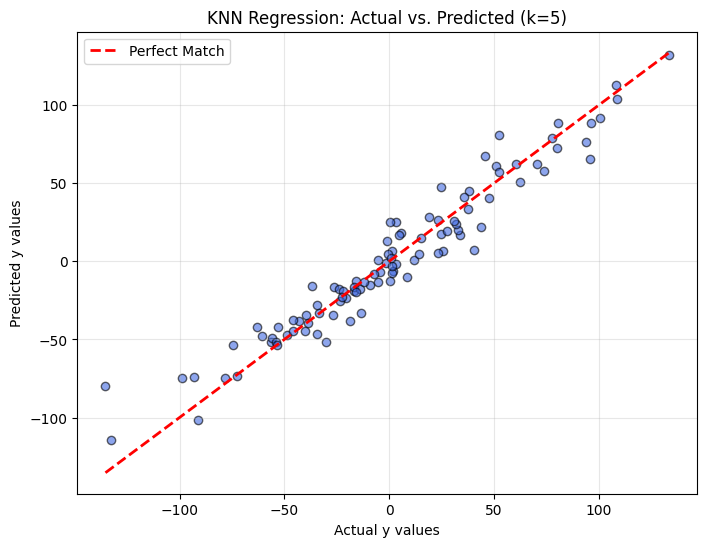

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions, alpha=0.6, color='royalblue', edgecolors='k')


min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label="Perfect Match")

plt.title(f"KNN Regression: Actual vs. Predicted (k={model.k})")
plt.xlabel("Actual y values")
plt.ylabel("Predicted y values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()